# Aim of this notebook
This notebook shows how to use the FAIR-Checker API with a set of custom metadata profiles, 
to evaluate the completeness of metadata for a set of DOIs or URLs.

The metadata profile is based on the Datacite Metadata Schema. 
A profile is defined as a set of mandatory, recommended and optional metadata elements. 

A global completeness score is computed for each evaluated metadata, based on the presence of mandatory, recommended and optional elements.
A specific weight is given to each element, based on its importance for the FAIRness of the metadata.

The FAIR-Checker API is better described at https://fair-checker.france-bioinformatique.fr/swagger 

Please report any issue at https://github.com/IFB-ElixirFr/fair-checker/issues or contact alban.gaignard@univ-nantes.fr. 

In [10]:
import time
import requests
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from rdflib import Graph, ConjunctiveGraph, Namespace, RDF, URIRef, Literal


## Input dataset

In [3]:
DOIs = [
    "https://doi.org/10.60641/91cv-vn58",
    "https://doi.org/10.48550/arxiv.2405.15830",
    "https://doi.org/10.5281/zenodo.6278497",
]

datacite_prefix = "https://api.datacite.org/application/vnd.schemaorg.ld+json/"

DOIs_datacite_jsonld = []
for doi in DOIs:
    # Replace the DOI prefix with the DataCite JSON-LD endpoint
    if doi.startswith("https://doi.org/"):
        DOIs_datacite_jsonld.append(doi.replace("https://doi.org/", datacite_prefix))

DOIs += DOIs_datacite_jsonld
print(DOIs)

['https://doi.org/10.60641/91cv-vn58', 'https://doi.org/10.48550/arxiv.2405.15830', 'https://doi.org/10.5281/zenodo.6278497', 'https://api.datacite.org/application/vnd.schemaorg.ld+json/10.60641/91cv-vn58', 'https://api.datacite.org/application/vnd.schemaorg.ld+json/10.48550/arxiv.2405.15830', 'https://api.datacite.org/application/vnd.schemaorg.ld+json/10.5281/zenodo.6278497']


# Datacite profile version 4.6 
as stated in "https://datacite-metadata-schema.readthedocs.io/en/4.6/properties/overview/#levels-of-obligation" 

In [ ]:
# mandatory_fields = [
#     "identifier",
#     "creator",
#     "title",
#     "publisher",
#     "publicationYear",
#     "resourceType"
# ]

# recommended_fields = [
#     "subject",
#     "contributor",
#     "date",
#     "relatedIdentifier",
#     "description", 
#     "geoLocation", 
# ]

# optional_fields = [
#     "language",
#     "alternateIdentifier",
#     "size",
#     "format",
#     "version",
#     "rights",
#     "fundingReference", 
#     "relatedItem"
# ]

# can be mapped to DCterms as follows:
# https://datacite-metadata-schema.readthedocs.io/en/4.6/mappings/ 

# mandatory_dct_properties = [
#     "dc:identifier", # http://purl.org/dc/terms/identifier 
#     "dc:creator", # http://purl.org/dc/terms/creator
#     "dc:title", # http://purl.org/dc/terms/title
#     "dc:publisher", # http://purl.org/dc/terms/publisher 
#     "dc:issued", # http://purl.org/dc/terms/issued
#     "dc:type" # http://purl.org/dc/terms/type
# ]

# recommended_dct_properties = [
#     "dc:subject",   # http://purl.org/dc/terms/subject
#     "dc:contributor", # http://purl.org/dc/terms/contributor
#     "dc:date", # http://purl.org/dc/terms/date
#     "dc:relation", # http://purl.org/dc/terms/relation or one of isReferencedBy, isPartOf, hasPart, isVersionOf, hasVersion ... 
#     "dc:description", # http://purl.org/dc/terms/description
#     "dc:spatial", # http://purl.org/dc/terms/spatial
# ]

# optional_dct_properties = [
#     "dc:language", # http://purl.org/dc/terms/language
#     #"dc:alternateIdentifier", # http://purl.org/dc/terms/alternative
#     #"dc:size", # 
#     "dc:format", # http://purl.org/dc/terms/format
#     "dc:hasVersion", # http://purl.org/dc/terms/hasVersion
#     "dc:rights", # http://purl.org/dc/terms/rights
#     #"dc:fundingReference",  
#     #"dc:relatedItem" 
# ]

# datacite_profile = {
#     "target_class": ["http://schema.org/Dataset"],
#     "mandatory_properties": mandatory_dct_properties,
#     "recommended_properties": recommended_dct_properties,
#     "optional_properties": optional_dct_properties,
# }

In [27]:
### Mapping with  Schema.org 
mandatory_schema_properties = [
    "http://schema.org/identifier", 
    "http://schema.org/creator", # or schema:author 
    "http://schema.org/name", 
    "http://schema.org/publisher", 
    "http://schema.org/datePublished", 
]

recommended_schema_properties = [
    "http://schema.org/about",  
    "http://schema.org/contributor", # or schema:author
    "http://schema.org/dateCreated", # or schema:dateCreated
    "http://schema.org/isPartOf", # or one of isReferencedBy, isPartOf, hasPart, isVersionOf, hasVersion ... 
    "http://schema.org/description", # or schema:abstract
    "http://schema.org/spatialCoverage", # or schema:location
]

optional_schema_properties = [
    "http://schema.org/inLanguage", #
    #"http://schema.org/alternateIdentifier", # http://purl.org/dc/terms/alternative
    #"http://schema.org/size", # 
    "http://schema.org/encodingFormat", # http://purl.org/dc/terms/format
    "http://schema.org/version", # http://purl.org/dc/terms/hasVersion
    "http://schema.org/license", # http://purl.org/dc/terms/rights
    #"http://schema.org/fundingReference",  
    #"http://schema.org/relatedItem" 
]

schema_profile = {
    "target_class": ["http://schema.org/CreativeWork"],
    "mandatory_properties": mandatory_schema_properties,
    "recommended_properties": recommended_schema_properties,
    "optional_properties": optional_schema_properties,
}

# Generic SHACL shape for metadata completeness evaluation

In [33]:
from jinja2 import Template

shape_tpl = """
    @prefix ns: <https://fair-checker.france-bioinformatique.fr#> .
    @prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
    @prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
    @prefix sc: <http://schema.org/> .
    @prefix scs: <https://schema.org/> .
    @prefix bsc: <https://bioschemas.org/> .
    @prefix dct: <http://purl.org/dc/terms/> .
    @prefix sh: <http://www.w3.org/ns/shacl#> .
    @prefix xsd: <http://www.w3.org/2001/XMLSchema#> .
    @prefix edam: <http://edamontology.org/> .
    @prefix biotools: <https://bio.tools/ontology/> .

    {% for target_class in target_classes %}
    ns:test_NG_shape_{{ loop.index }}
        a sh:NodeShape ;
        sh:targetClass <{{target_class}}> ;

        {% for min_prop in min_props %}
                sh:property [
                    sh:path <{{min_prop}}> ;
                    sh:minCount 1 ;
                    sh:severity sh:Violation
                ] ;
        {% endfor %}

        {% for rec_prop in rec_props %}
                sh:property [
                    sh:path <{{rec_prop}}> ;
                    sh:minCount 1 ;
                    sh:severity sh:Warning
                ] ;
        {% endfor %}
        
        {% for opt_prop in opt_props %}
                sh:property [
                    sh:path <{{opt_prop}}> ;
                    sh:minCount 1 ;
                    sh:severity sh:Info
                ] ;
        {% endfor %}
    .
    {% endfor %}
"""

template = Template(shape_tpl)
person_shape = template.render(
    target_classes=md_profile["target_class"],
    min_props=md_profile["mandatory_properties"],
    rec_props=md_profile["recommended_properties"],
    opt_props=md_profile["optional_properties"]
)

datacite_shape = template.render(
    target_classes=datacite_profile["target_class"],
    min_props=datacite_profile["mandatory_properties"],
    rec_props=datacite_profile["recommended_properties"],
    opt_props=datacite_profile["optional_properties"]
)

schema_shape = template.render(
    target_classes=schema_profile["target_class"],
    min_props=schema_profile["mandatory_properties"],
    rec_props=schema_profile["recommended_properties"],
    opt_props=schema_profile["optional_properties"]
)
print(schema_shape)
#print(datacite_shape)
# print(template.render(
#     target_classes=md_profile["target_class"],
#     min_props=md_profile["mandatory_properties"],
#     rec_props=md_profile["recommended_properties"],
#     opt_props=md_profile["optional_properties"]
# ))


    @prefix ns: <https://fair-checker.france-bioinformatique.fr#> .
    @prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
    @prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
    @prefix sc: <http://schema.org/> .
    @prefix scs: <https://schema.org/> .
    @prefix bsc: <https://bioschemas.org/> .
    @prefix dct: <http://purl.org/dc/terms/> .
    @prefix sh: <http://www.w3.org/ns/shacl#> .
    @prefix xsd: <http://www.w3.org/2001/XMLSchema#> .
    @prefix edam: <http://edamontology.org/> .
    @prefix biotools: <https://bio.tools/ontology/> .

    
    ns:test_NG_shape_1
        a sh:NodeShape ;
        sh:targetClass <http://schema.org/CreativeWork> ;

        
                sh:property [
                    sh:path <http://schema.org/identifier> ;
                    sh:minCount 1 ;
                    sh:severity sh:Violation
                ] ;
        
                sh:property [
                    sh:path <http://schema.org/creator> ;
                   

## Evaluation of SHACL shapes 

In [29]:
from rdflib import Graph, RDF
from pyshacl import validate

def validate_shape(knowledge_graph, shacl_shape):
    r = validate(
        data_graph=knowledge_graph,
        data_graph_format="turtle",
        shacl_graph=shacl_shape,
        # shacl_graph = my_shacl_constraint,
        shacl_graph_format="turtle",
        ont_graph=None,
        inference="rdfs",
        abort_on_first=False,
        meta_shacl=False,
        debug=False,
    )

    conforms, results_graph, results_text = r

    report_query = """
            SELECT ?node ?path ?path ?severity WHERE {
                ?v rdf:type sh:ValidationReport ;
                   sh:result ?r .
                ?r sh:focusNode ?node ;
                   sh:sourceShape ?s .
                { ?s sh:path ?path ;
                   sh:severity ?severity . }
                UNION { ?s sh:path/sh:alternativePath/rdf:rest*/rdf:first ?path ;
                   sh:severity ?severity . }
                FILTER (! isBlank(?path))
            }
        """

    results = results_graph.query(report_query)
    # print("VALIDATION RESULTS")
    # print(results_text)
    # print(conforms)
    # print(results_graph.serialize(format="turtle"))
    warnings = []
    errors = []
    infos = []
    for r in results:
        if "#Warning" in r["severity"]:
            # print(f'WARNING: Property {r["path"]} should be provided for {r["node"]}')
            warnings.append(f'{r["path"]}')
        if "#Violation" in r["severity"]:
            # print(f'ERROR: Property {r["path"]} must be provided for {r["node"]}')
            errors.append(f'{r["path"]}')
        if "#Info" in r["severity"]:
            # print(f'INFO: Property {r["path"]} is recommended for {r["node"]}')
            infos.append(f'{r["path"]}')

    return conforms, infos, warnings, errors

## Metadata completeness evaluation based on a custom profile

In [34]:
def validate_md(graph, profile):
    # print(f"Validating metadata with the {profile['target_class']} profile...")
    # print(f"Graph size: {len(graph)} triples")

    # print(template.render(
    #     target_classes=profile["target_class"],
    #     min_props=profile["mandatory_properties"],
    #     rec_props=profile["recommended_properties"],
    #     opt_props=profile["optional_properties"]
    # ))

    shape = template.render(
        target_classes=profile["target_class"],
        min_props=profile["mandatory_properties"],
        rec_props=profile["recommended_properties"],
        opt_props=profile["optional_properties"]
    )

    try:
        shape_kg = Graph()
        shape_kg.parse(data=shape, format="turtle")
        assert (len(shape_kg) > 0)
        #print(f"Shape graph size: {len(shape_kg)} triples")
        #print(shape_kg.serialize(format="turtle"))
    except Exception as e:
        print("Error parsing the SHACL shape:", e)
        print("Shape content was:")
        print(shape)
        return
    
    results = {}
    
    print()
    for s, p, o in graph.triples((None, RDF.type, None)):
        
        # print(f"{s.n3(graph.namespace_manager)} is a {o.n3(graph.namespace_manager)}")
        # print(f"Profile target classes: {profile['target_class']}")
        # print(str(o))

        #if o.n3(graph.namespace_manager) in profile["target_class"]:
        if str(o) in profile["target_class"]:
            
            sub_kg = Graph()
            for x, y, z in graph.triples((s, None, None)):
                sub_kg.add((x, y, z))

            conforms, infos, warnings, errors = validate_shape(
                knowledge_graph=sub_kg, shacl_shape=shape
            )
            print(f"Validation result for {s} (type: {o}): conforms={conforms}, infos={infos}, warnings={warnings}, errors={errors}")

            results[str(s)] = {
                "type": str(o),
                "ref_profile": profile["target_class"],
                "conforms": conforms,
                "infos": infos,
                "warnings": warnings,
                "errors": errors,
            }

            n_warnings = len(results[str(s)]["warnings"])
            n_errors = len(results[str(s)]["errors"])
            n_infos = len(results[str(s)]["infos"])
            n_profile_min_props = len(profile["mandatory_properties"])
            n_profile_rec_props = len(profile["recommended_properties"])
            n_profile_opt_props = len(profile["optional_properties"])

            completeness_score = round(
                (3 * (n_profile_min_props - n_errors) + 2 * (n_profile_rec_props - n_warnings) + 1 * (n_profile_opt_props - n_infos))
                * 100
                / (3 * (n_profile_min_props) + 2 * (n_profile_rec_props) + 1 * (n_profile_opt_props)),
                2,
            )  

            results[str(s)]["completeness_score"] = completeness_score
            
    return results

## Toy examples with a custom profile for schema:Person instances

In [35]:
from rdflib import Graph 

person_ttl = """
    @prefix sc2: <http://schema.org/> .
    <https://example.org/person/1> a sc2:Person ;
        sc2:names "John Bad" .

    <https://example.org/person/2> a sc2:Person ;
        sc2:email "john.medium@example.org" .

    <https://example.org/person/3> a sc2:Person ;
        sc2:name "John medium" .

    <https://example.org/person/4> a sc2:Person ;
        sc2:name "John Good" ;
        sc2:email "john.good@example.org" ;
        sc2:phone "+123456789" .
"""

kg = Graph()
kg.parse(data=person_ttl, format="turtle")
print(f'loaded graph with {len(kg)} triples')

md_profile = {
    "target_class": ["http://schema.org/Person"],
    "mandatory_properties": ["http://schema.org/name"],
    "recommended_properties": ["http://schema.org/email"],
    "optional_properties": ["http://schema.org/phone"],
}

res = validate_md(kg, md_profile)
print()
print("Validation results:")
for s, r in res.items():
    print(f"Subject: {s}")
    print(f"Type: {r['type']}")
    print(f"Conforms: {r['conforms']}")
    print(f"Completeness score: {r['completeness_score']}%")
    print()

loaded graph with 10 triples

Validation result for https://example.org/person/1 (type: http://schema.org/Person): conforms=False, infos=['http://schema.org/phone'], warnings=['http://schema.org/email'], errors=['http://schema.org/name']
Validation result for https://example.org/person/2 (type: http://schema.org/Person): conforms=False, infos=['http://schema.org/phone'], warnings=[], errors=['http://schema.org/name']
Validation result for https://example.org/person/3 (type: http://schema.org/Person): conforms=False, infos=['http://schema.org/phone'], warnings=['http://schema.org/email'], errors=[]
Validation result for https://example.org/person/4 (type: http://schema.org/Person): conforms=True, infos=[], warnings=[], errors=[]

Validation results:
Subject: https://example.org/person/1
Type: http://schema.org/Person
Conforms: False
Completeness score: 0.0%

Subject: https://example.org/person/2
Type: http://schema.org/Person
Conforms: False
Completeness score: 33.33%

Subject: https://

## Evaluation of a set of DOIs with the Datacite profile

In [36]:
from rdflib import Dataset
import json

FC_get_md = "https://fair-checker.france-bioinformatique.fr/api/inspect/get_rdf_metadata"

test = ["https://doi.org/10.48550/arxiv.2405.15830", 
        "https://api.datacite.org/application/vnd.schemaorg.ld+json/10.48550/arxiv.2405.15830", 
        "https://doi.org/10.82235/wajr.vol27no2.83", 
        "https://api.datacite.org/application/vnd.schemaorg.ld+json/10.82235/wajr.vol27no2.83"]

schema_profile = {
    "target_class": ["http://schema.org/CreativeWork", "http://schema.org/ScholarlyArticle", "http://schema.org/Dataset"],
    "mandatory_properties": mandatory_schema_properties,
    "recommended_properties": recommended_schema_properties,
    "optional_properties": optional_schema_properties,
}
print(json.dumps(schema_profile, indent=2))

data = {}

#for doi in DOIs:
for doi in test:
    print(f"Extracting {doi} RDF metadata with FAIR-Checker...")
    res = requests.get(url=FC_get_md, params={"url": doi})
    kg = ConjunctiveGraph()
    try:
        kg.parse(data=res.text, format="json-ld")
        kg.serialize(destination="test.ttl", format="turtle")
        #print(f'loaded graph with {len(kg)} triples')
        #print(kg.serialize(format="trig"))
    except Exception as e:
        print(e)
    
    res = validate_md(kg, schema_profile)
    for url in res.keys():
        print(res[url])
        data[url] = res[url]["completeness_score"]
        


{
  "target_class": [
    "http://schema.org/CreativeWork",
    "http://schema.org/ScholarlyArticle",
    "http://schema.org/Dataset"
  ],
  "mandatory_properties": [
    "http://schema.org/identifier",
    "http://schema.org/creator",
    "http://schema.org/name",
    "http://schema.org/publisher",
    "http://schema.org/datePublished"
  ],
  "recommended_properties": [
    "http://schema.org/about",
    "http://schema.org/contributor",
    "http://schema.org/dateCreated",
    "http://schema.org/isPartOf",
    "http://schema.org/description",
    "http://schema.org/spatialCoverage"
  ],
  "optional_properties": [
    "http://schema.org/inLanguage",
    "http://schema.org/encodingFormat",
    "http://schema.org/version",
    "http://schema.org/license"
  ]
}
Extracting https://doi.org/10.48550/arxiv.2405.15830 RDF metadata with FAIR-Checker...


/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_84900/2162213128.py:25: DeprecationWarning: ConjunctiveGraph is deprecated, use Dataset instead.
  kg = ConjunctiveGraph()



Extracting https://api.datacite.org/application/vnd.schemaorg.ld+json/10.48550/arxiv.2405.15830 RDF metadata with FAIR-Checker...

Validation result for https://doi.org/10.48550/arxiv.2405.15830 (type: http://schema.org/CreativeWork): conforms=False, infos=['http://schema.org/inLanguage', 'http://schema.org/encodingFormat'], warnings=['http://schema.org/about', 'http://schema.org/contributor', 'http://schema.org/dateCreated', 'http://schema.org/isPartOf', 'http://schema.org/spatialCoverage'], errors=['http://schema.org/creator']
{'type': 'http://schema.org/CreativeWork', 'ref_profile': ['http://schema.org/CreativeWork', 'http://schema.org/ScholarlyArticle', 'http://schema.org/Dataset'], 'conforms': False, 'infos': ['http://schema.org/inLanguage', 'http://schema.org/encodingFormat'], 'warnings': ['http://schema.org/about', 'http://schema.org/contributor', 'http://schema.org/dateCreated', 'http://schema.org/isPartOf', 'http://schema.org/spatialCoverage'], 'errors': ['http://schema.org/c

## Results visualization

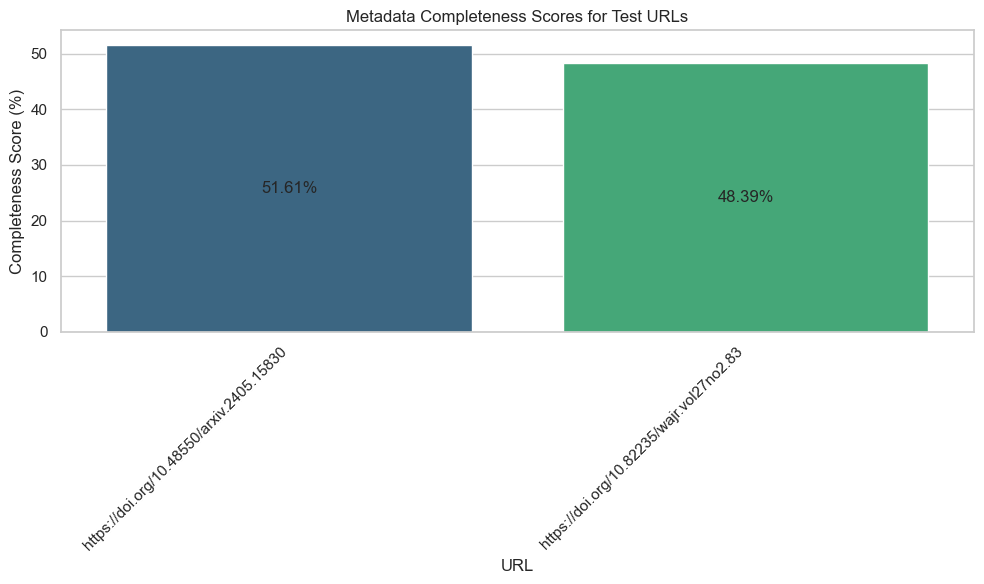

In [39]:
import seaborn as sns
# do the same with seaborn
plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid")
sns.barplot(data=pd.DataFrame.from_dict(data, orient='index', columns=['completeness_score']), x=data.keys(), hue=data.keys(), y="completeness_score", palette="viridis", legend=False)  

# print the value of each bar in the center of the bar
for index, value in enumerate(data.values()):
    plt.text(index, value / 2, f"{value}%", ha='center', va='center')

plt.xlabel('URL')
plt.ylabel('Completeness Score (%)')
plt.title('Metadata Completeness Scores for Test URLs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()